### MIEMBROS DEL GRUPO
### QISONG WANG, 100522127
### XUECHENG ZHANG, 100522197

# 0. PASOS PREVIOS AL TRABAJO

Instalación de la librerías necesarias:

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importación de las librerías necesarias y creación de la semilla:

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

RANDOM_SEED = 100522127

# 1. PREPROCESADO

Cargamos el dataset y comprobamos los atributos que presenta (aunque ya aparece detallado en el enunciado):

In [3]:
df = pd.read_csv("stars_data.csv")
df.head()

,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [4]:
print("Clases Espectrales:", df['Spectral_Class'].unique())
print("Colores:", df['Color'].unique())

Clases Espectrales: <ArrowStringArray>
['M', 'B', 'A', 'F', 'O', 'K', 'G']
Length: 7, dtype: str
Colores: <ArrowStringArray>
[               'Red',         'Blue White',              'White',
    'Yellowish White',         'Blue white', 'Pale yellow orange',
               'Blue',         'Blue-white',            'Whitish',
       'yellow-white',             'Orange',       'White-Yellow',
              'white',          'yellowish',          'Yellowish',
         'Orange-Red',         'Blue-White']
Length: 17, dtype: str


Para la codificación de las variables categóricas (`Color` y `Spectral_Class`), se ha optado por una codificación ordinal siguiendo un criterio físico. Tal y como sugiere el enunciado, el orden de las categorías se ha establecido en función de la cantidad de energía y temperatura asociada (de menor a mayor). Esto permite a los algoritmos posteriores interpretar correctamente la relación de magnitud entre estas clases.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

df['Color'] = df['Color'].str.lower()
replace_color = {
    'blue': 'blue',
    'blue white': 'blue-white',
    'blue-white': 'blue-white',
    'white': 'white',
    'whitish': 'white',
    'yellow-white': 'yellow-white',
    'white-yellow': 'yellow-white',
    'yellowish white': 'yellow-white',
    'pale yellow orange': 'yellowish',
    'yellowish': 'yellowish',
    'orange': 'orange',
    'orange-red': 'orange-red',
    'red': 'red'
}
df['Color'] = df['Color'].replace(replace_color)

order_spectral_class = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
order_color_class = ['blue', 'blue-white', 'white', 'yellow-white', 'yellowish', 'orange', 'orange-red', 'red']

encoder = OrdinalEncoder(categories=[order_spectral_class, order_color_class])
df[['Spectral_Class', 'Color']] = encoder.fit_transform(df[['Spectral_Class', 'Color']])

print("Valores nulos tras el mapeo:\n", df.isnull().sum())

Valores nulos tras el mapeo:
 Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64


# 2. MODIFICACIÓN DE LA DIMENSIONALIDAD

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

data_modified_pca = pipeline.fit_transform(df)
df_pca = pd.DataFrame(data=data_modified_pca, columns=['PC1', 'PC2'])
X = df_pca.copy()

modelo_pca = pipeline.named_steps['pca']

varianza_explicada = modelo_pca.explained_variance_ratio_

print(f"Varianza retenida por la PC1: {varianza_explicada[0]}")
print(f"Varianza retenida por la PC2: {varianza_explicada[1]}")
print(f"Varianza total explicada en 2D: {sum(varianza_explicada)}")

Varianza retenida por la PC1: 0.5560971750241077
Varianza retenida por la PC2: 0.29609764402748523
Varianza total explicada en 2D: 0.8521948190515929


Tras aplicar el escalado de los datos (paso fundamental previo a PCA), la reducción a 2 componentes principales logra retener un 85.22% de la varianza total. Este es un valor suficientemente alto que garantiza la conservación de la mayor parte de la información original, permitiendo una correcta visualización en 2D y un cálculo de distancias eficiente para los algoritmos de clustering.

# 3. ALGORTIMOS DE CLUSTERING

## 3.1 K-MEANS


,k,inercia,silhouette
0,2,609.702306,0.506081
1,3,338.182775,0.584611
2,4,170.153859,0.633448
3,5,106.189731,0.649172
4,6,82.398016,0.657763
5,7,63.543874,0.642649
6,8,54.044251,0.637009
7,9,47.390463,0.611737
8,10,41.912690,0.621290


Mejor k según silhouette: 6


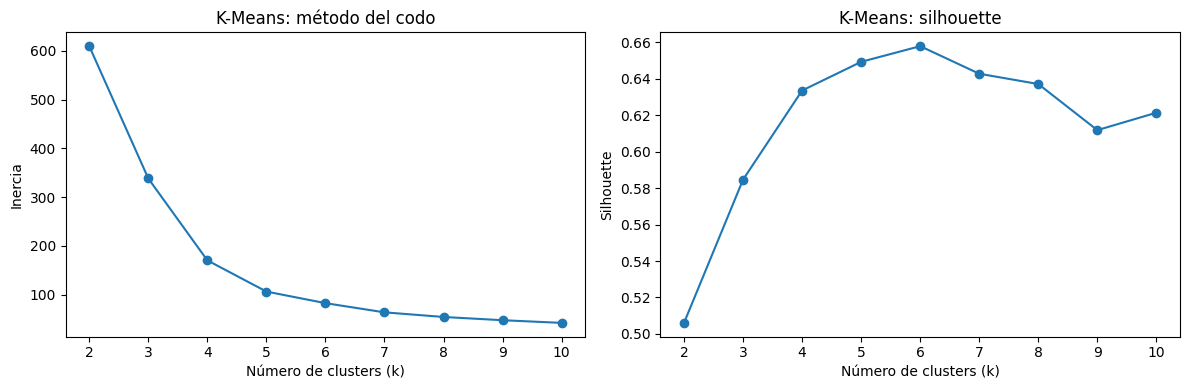

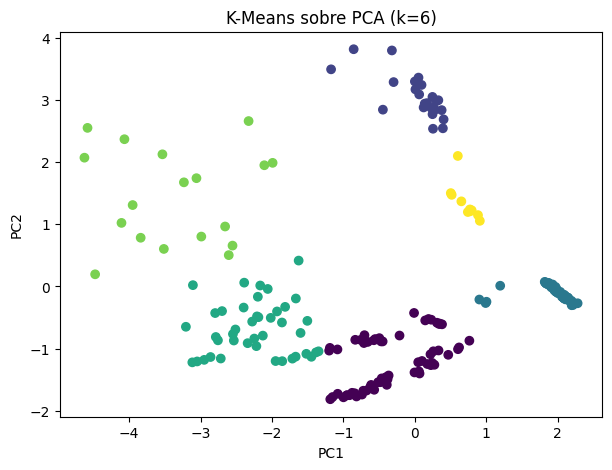

In [7]:
k_values = range(2, 11)
resultados_kmeans = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = modelo.fit_predict(X)

    resultados_kmeans.append({
        'k': k,
        'inercia': modelo.inertia_,
        'silhouette': silhouette_score(X, labels)
    })

resultados_kmeans = pd.DataFrame(resultados_kmeans)
display(resultados_kmeans)

best_k = int(resultados_kmeans.loc[resultados_kmeans['silhouette'].idxmax(), 'k'])
print(f"Mejor k según silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(resultados_kmeans['k'], resultados_kmeans['inercia'], marker='o')
axes[0].set_title('K-Means: método del codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(resultados_kmeans['k'], resultados_kmeans['silhouette'], marker='o')
axes[1].set_title('K-Means: silhouette')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=20)
labels_kmeans = kmeans_final.fit_predict(X)

df_kmeans = df_pca.copy()
df_kmeans['cluster_kmeans'] = labels_kmeans

plt.figure(figsize=(7, 5))
plt.scatter(df_kmeans['PC1'], df_kmeans['PC2'], c=df_kmeans['cluster_kmeans'])
plt.title(f'K-Means sobre PCA (k={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

Al observar las gráficas de evaluación, el método de la inercia (codo) no muestra un punto de inflexión completamente evidente. Sin embargo, la métrica Silhouette indica de forma clara que el agrupamiento óptimo de los datos en este espacio reducido se consigue seleccionando `k=6` clústeres.

## 3.2 CLUSTERING JERÁRQUICO

,linkage,k,silhouette
12,complete,5,0.637966
21,average,5,0.632804
24,average,8,0.631831
5,ward,7,0.631001
23,average,7,0.630152
8,ward,10,0.624950
22,average,6,0.624494
2,ward,4,0.624430
25,average,9,0.622449
6,ward,8,0.622401


Mejor clustering jerárquico: linkage=complete, k=5


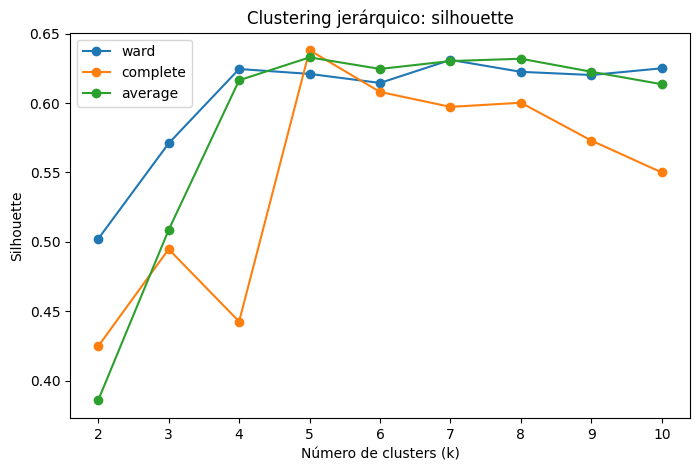

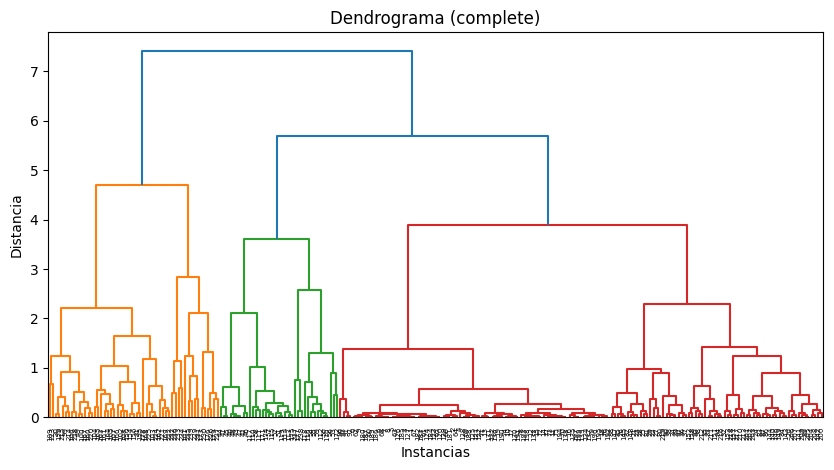

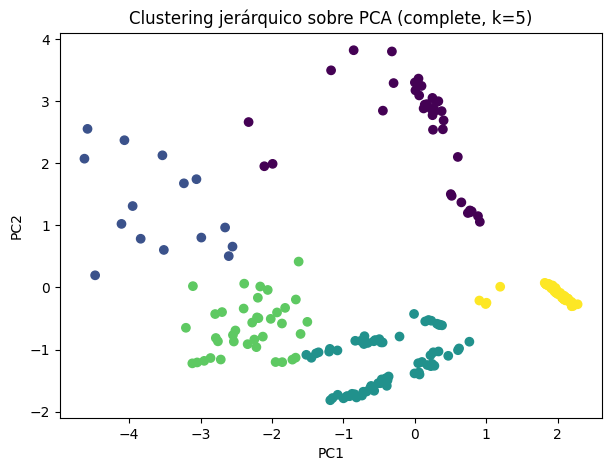

In [8]:
linkage_methods = ['ward', 'complete', 'average']
k_values = range(2, 11)

resultados_hc = []

for metodo in linkage_methods:
    for k in k_values:
        modelo = AgglomerativeClustering(n_clusters=k, linkage=metodo)
        labels = modelo.fit_predict(X)

        resultados_hc.append({
            'linkage': metodo,
            'k': k,
            'silhouette': silhouette_score(X, labels)
        })

resultados_hc = pd.DataFrame(resultados_hc)
display(resultados_hc.sort_values('silhouette', ascending=False))

mejor_hc = resultados_hc.loc[resultados_hc['silhouette'].idxmax()]
best_linkage = mejor_hc['linkage']
best_k_hc = int(mejor_hc['k'])

print(f"Mejor clustering jerárquico: linkage={best_linkage}, k={best_k_hc}")

plt.figure(figsize=(8, 5))
for metodo in linkage_methods:
    datos_plot = resultados_hc[resultados_hc['linkage'] == metodo]
    plt.plot(datos_plot['k'], datos_plot['silhouette'], marker='o', label=metodo)

plt.title('Clustering jerárquico: silhouette')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette')
plt.legend()
plt.show()

Z = linkage(X, method=best_linkage)

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title(f'Dendrograma ({best_linkage})')
plt.xlabel('Instancias')
plt.ylabel('Distancia')
plt.show()

hc_final = AgglomerativeClustering(n_clusters=best_k_hc, linkage=best_linkage)
labels_hc = hc_final.fit_predict(X)

df_hc = df_pca.copy()
df_hc['cluster_hc'] = labels_hc

plt.figure(figsize=(7, 5))
plt.scatter(df_hc['PC1'], df_hc['PC2'], c=df_hc['cluster_hc'])
plt.title(f'Clustering jerárquico sobre PCA ({best_linkage}, k={best_k_hc})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

La evaluación iterativa de los diferentes métodos de enlace (linkage) mediante la métrica Silhouette muestra que el método `complete` agrupado en `k=5` clústeres obtiene el mejor rendimiento para este conjunto de datos. El dendrograma generado confirma visualmente esta estructura jerárquica y las distancias a las que se fusionan los diferentes grupos.

## 3.3 DBSCAN

Para la optimización y evaluación del algoritmo DBSCAN, se realiza una búsqueda en rejilla de los hiperparámetros `eps` y `min_samples`, evaluando los resultados mediante la métrica específica DBCV aplicada únicamente sobre los puntos considerados como núcleo o frontera.

Mejor DBCV Score: 0.9472
Mejores hiperparámetros: eps = 0.10, min_samples = 7


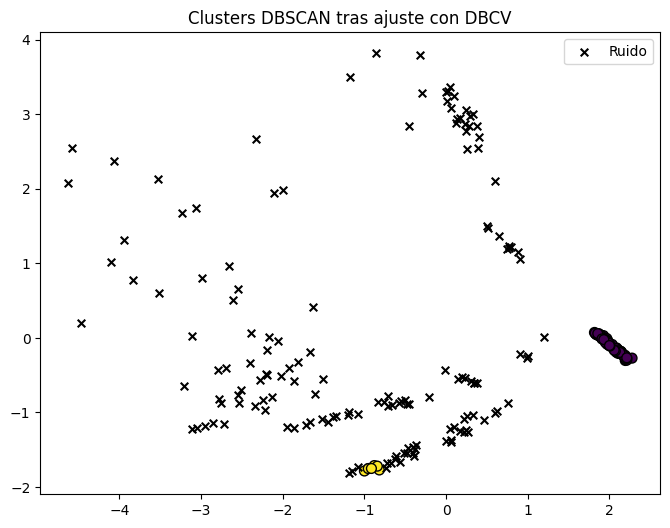

In [9]:
from DBCV import DBCV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

eps_values = np.arange(0.1, 1.6, 0.1) 
min_samples_values = range(3, 10)

best_score = -1.0 
best_eps = None
best_min_samples = None
best_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            mask = labels != -1
            X_filtered = X.values[mask]
            labels_filtered = labels[mask]
            
            try:
                score = DBCV(X_filtered, labels_filtered) 
                
                if score > best_score:
                    best_score = score
                    best_eps = eps
                    best_min_samples = min_samples
                    best_labels = labels 
                    
            except Exception:
                pass

if best_eps is not None:
    print(f"Mejor DBCV Score: {best_score:.4f}")
    print(f"Mejores hiperparámetros: eps = {best_eps:.2f}, min_samples = {best_min_samples}")
    
    ruido = best_labels == -1
    clusters = best_labels != -1

    plt.figure(figsize=(8, 6))
    plt.scatter(X.loc[clusters, 'PC1'], X.loc[clusters, 'PC2'], c=best_labels[clusters], cmap='viridis', s=50, edgecolors='k')
    plt.scatter(X.loc[ruido, 'PC1'], X.loc[ruido, 'PC2'], c='black', marker='x', s=30, label='Ruido')
    plt.legend()
    plt.title('Clusters DBSCAN tras ajuste con DBCV')
    plt.show()

# 4. PIPELINE RECOMENDADO

A partir de los resultados obtenidos, se recomienda utilizar el siguiente pipeline:

`StandardScaler → PCA(n_components=2) → KMeans(n_clusters=6, random_state=100522127)`

Primero se estandarizan los datos porque las variables tienen escalas muy diferentes y los algoritmos de clustering trabajan con distancias. Después se aplica PCA con 2 componentes. En nuestro caso, estas dos componentes explican aproximadamente el 85.22% de la varianza total, por lo que conservan una parte importante de la información original.

Sobre las componentes principales, K-Means obtiene el mejor resultado entre los métodos comparables mediante silhouette. Con `k=6` alcanza un silhouette aproximado de 0.6578.

Aunque DBSCAN obtiene un valor alto de DBCV con `eps=0.10` y `min_samples=7`, no se recomienda como pipeline final porque esta métrica no es directamente comparable con silhouette y porque DBSCAN puede dejar estrellas clasificadas como ruido.

Por tanto, se recomienda K-Means con `n_clusters=6`, ya que ofrece el mejor resultado de silhouette, asigna todas las estrellas a un cluster y genera un número de grupos coherente con las seis clases astronómicas de referencia del enunciado.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pipeline_recomendado = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("kmeans", KMeans(
        n_clusters=6,
        random_state=RANDOM_SEED,
        n_init=20
    ))
])

labels_pipeline_recomendado = pipeline_recomendado.fit_predict(df)

# 5. Comparación con las clases astronómicas

Para comparar los clusters obtenidos con las clases astronómicas del enunciado, se ha usado el pipeline recomendado en el apartado anterior: `StandardScaler → PCA(n_components=2) → KMeans(n_clusters=6)`. Aunque el clustering se realiza sobre las componentes principales, la interpretación se hace usando las variables originales.

Para ello, se ha añadido a cada estrella su cluster y se han calculado los valores medios de temperatura, luminosidad, radio y magnitud absoluta, junto con el color y la clase espectral más frecuentes de cada grupo.

En general, sí se observan similitudes entre los clusters y las clases astronómicas. Los grupos con menor temperatura, baja luminosidad y color rojizo se aproximan a enanas rojas o marrones. Los grupos con temperatura alta, radio pequeño y color blanco pueden relacionarse con enanas blancas. Los clusters con luminosidad y radio muy elevados, junto con magnitudes absolutas bajas o negativas, se parecen a supergigantes o hipergigantes. Por último, los grupos con valores intermedios pueden asociarse con estrellas de secuencia principal.

La correspondencia no es exacta, ya que el agrupamiento es no supervisado y no utiliza las clases reales durante el ajuste. Aun así, los clusters obtenidos presentan perfiles físicos coherentes con la clasificación astronómica dada en el enunciado.

In [11]:
if 'labels_pipeline_recomendado' in globals():
    labels_recomendado = labels_pipeline_recomendado
else:
    labels_recomendado = labels_kmeans

df_interpretacion = df.copy()
df_interpretacion[['Spectral_Class', 'Color']] = encoder.inverse_transform(
    df_interpretacion[['Spectral_Class', 'Color']]
)

df_interpretacion['cluster'] = labels_recomendado

perfil_clusters = df_interpretacion.groupby('cluster').agg(
    n_estrellas=('Temperature', 'size'),
    Temperature_media=('Temperature', 'mean'),
    L_media=('L', 'mean'),
    R_media=('R', 'mean'),
    A_M_media=('A_M', 'mean'),
    Color_moda=('Color', lambda x: x.mode().iloc[0]),
    Spectral_Class_moda=('Spectral_Class', lambda x: x.mode().iloc[0])
).round(2)

perfil_clusters

,n_estrellas,Temperature_media,L_media,R_media,A_M_media,Color_moda,Spectral_Class_moda
cluster,,,,,,,
0,62,12522.15,133.97,1.25,8.42,blue-white,B
1,24,3782.38,245541.67,1391.88,-9.92,red,M
2,84,3213.88,0.02,0.26,14.60,red,M
3,42,21793.36,203221.86,52.88,-5.55,blue,O
4,18,24015.89,512365.61,1105.39,-8.73,blue,O
5,10,3466.80,206600.00,129.50,-6.80,red,M
